In [22]:
%reset -f
%reload_ext autoreload
%autoreload 2

In [ ]:
import os,sys
current_path = os.getcwd()
sys.path.append("/home/zhuchen/poc/scorecard") 
sys.path.append("/home/zhuchen/poc/02-xyf2/config") 

In [24]:
name = current_path.split('/')[-1].split('_')
data = name[0]
cust = name[1]

In [25]:
print(name)

['deltaV1', 'all']


In [ ]:
FILE_PATH = f'/home/zhuchen/poc/02-xyf2/{data}_{cust}/file/'
DATA_PATH = f'/home/zhuchen/poc/02-xyf2/{data}_{cust}/data/'
TMP_PATH  = f'/home/zhuchen/poc/02-xyf2/{data}_{cust}/tmp/'
DATA_OR_PATH = '/home/zhuchen/poc/02-xyf2/data_or/'

In [27]:
import pandas as pd 
import numpy as np  
import math  
import matplotlib.pyplot as plt
import copy
import seaborn as sns
from pylab import mpl
import temp_config 

isExists=os.path.exists(FILE_PATH)
if not isExists:
    os.makedirs(FILE_PATH) 
    
isExists=os.path.exists(DATA_PATH)
if not isExists:
    os.makedirs(DATA_PATH) 

import warnings
warnings.filterwarnings("ignore")

In [28]:
#config cell
epoch = temp_config.epoch
print("epoch \n",epoch)

epoch 
 100


In [29]:
# optuna_index = temp_config.optuna_index
optuna_index = 0
print("optuna_index \n",optuna_index)

optuna_index 
 0


In [30]:
import gc
gc.collect()

54

In [31]:
# data_all = pd.read_pickle(DATA_PATH + 'data_end.pkl')
data_all = pd.read_csv(DATA_PATH + 'data_ft_2.csv')

In [32]:
ex_lst = ['mobile','backPointTime','qudao3_act','label',
 'weight',
 'target',
 'month_time',
 'day_time',
 'week_time',]
ft_lst = [i for i in data_all.columns if i not in ex_lst]
len(ft_lst)

print('num_feature: ', len(ft_lst))
print('data_shape: ', data_all.shape)

num_feature:  57
data_shape:  (1277742, 66)


In [33]:
best_flag = pd.read_csv(FILE_PATH + 'best_flag.csv')['best_flag'].tolist()[0]

In [34]:
from DataPreprocessing.Datasets.Split import by_stratify
data_all, res = by_stratify(data_all, 0.3, best_flag, date='backPointTime', dep='label')

         count  bad_rate      bad    time_min    time_max
all    1277742  0.046695  59664.0  2024-07-01  2025-06-22
train   803775  0.046010  36982.0  2024-07-01  2025-05-10
valid   344476  0.046009  15849.0  2024-07-01  2025-05-10
oot     129491  0.052768   6833.0  2025-05-11  2025-06-22
ratio_bad_good:  0.04822944393076097
train    803775
valid    344476
oot      129491
Name: target, dtype: int64


In [35]:
res

,count,bad_rate,bad,time_min,time_max
all,1277742,0.046695,59664.0,2024-07-01,2025-06-22
train,803775,0.046010,36982.0,2024-07-01,2025-05-10
valid,344476,0.046009,15849.0,2024-07-01,2025-05-10
oot,129491,0.052768,6833.0,2025-05-11,2025-06-22


### baseline

num_features:  57


XGBoost：
  datasets       auc  precision    recall        ks        f2        th  \
0    train  0.569755   0.051022  0.814829  0.096449  0.204012  0.039482   
0    valid  0.562588   0.050712  0.798410  0.088618  0.202189  0.039944   
0      oot  0.534705   0.056072  0.833748  0.057705  0.220927  0.036116   

      ratio   count  
0  0.734790  803775  
0  0.724370  344476  
0  0.784626  129491  
  datasets       auc        ks  precision    recall        f2        th  \
0    train  0.569755  0.096449   0.051022  0.814829  0.204012  0.039482   
0    valid  0.562588  0.088618   0.050712  0.798410  0.202189  0.039944   
0      oot  0.534705  0.057705   0.056072  0.833748  0.220927  0.036116   

      ratio   count  
0  0.734790  803775  
0  0.724370  344476  
0  0.784626  129491  


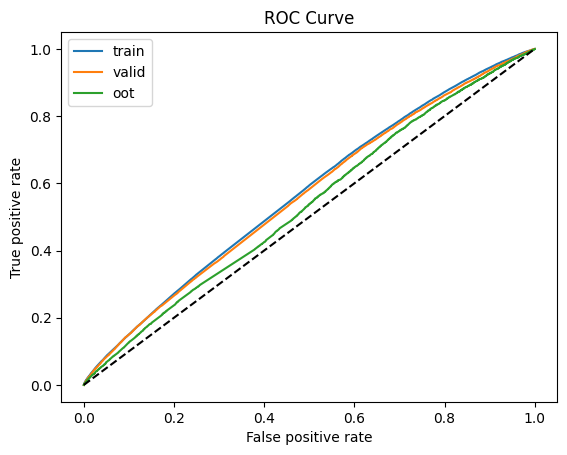

In [36]:
from Model.train import bi_train
res =  bi_train(data_all, dep='label', exclude=ex_lst, model_switch=[0, 1, 0, 0])

## 模型调参

In [37]:
# keep_lst = iv_keep
# data_end = data_all[keep_lst + ex_lst].copy()
# data_end.to_pickle(DATA_PATH + 'data_end_before_modeling.pkl')
# pd.DataFrame({'var_names':keep_lst}).to_csv('keep_lst.csv', index=False)
# len(keep_lst)

In [38]:
keep_lst = ft_lst
data_end = data_all

In [39]:
import gc
gc.collect()

3967

In [ ]:
from ParameterRegulation.Optuna import run, objective_fix_sample
file_path = FILE_PATH + 'optuna.xlsx'
print('epoch: ', epoch)
res_opt = run(objective_fix_sample, data_end, ex_lst, 1349, file_path, epoch, 'xgb', max_depth=2)

[I 2025-11-13 14:49:39,633] A new study created in memory with name: no-name-989e5c07-b0f0-4b3d-acac-2f683a6014a5


epoch:  100


[I 2025-11-13 14:49:43,572] Trial 0 finished with value: -0.07226353925540474 and parameters: {'reg_lambda': 0.012720062107171849, 'reg_alpha': 0.0069643801042967995, 'n_estimators': 54, 'max_depth': 4, 'min_child_weight': 2, 'learning_rate': 0.19669855399656136, 'col_sample_bytree': 0.2629065719130337, 'scale_pos_weight': 6.137804217948197, 'gamma': 0.18658022439969751, 'subsample': 0.9515734021768185}. Best is trial 0 with value: -0.07226353925540474.
[I 2025-11-13 14:49:48,104] Trial 1 finished with value: 0.07219061586428277 and parameters: {'reg_lambda': 2.7500779937352755, 'reg_alpha': 0.0009251350539915128, 'n_estimators': 91, 'max_depth': 4, 'min_child_weight': 3, 'learning_rate': 0.05299933002726735, 'col_sample_bytree': 0.20461235149034557, 'scale_pos_weight': 38.12884249008816, 'gamma': 0.14469492000411388, 'subsample': 0.8358269293151053}. Best is trial 1 with value: 0.07219061586428277.
[I 2025-11-13 14:49:51,527] Trial 2 finished with value: 0.07094080187822305 and parame

FrozenTrial(number=54, state=TrialState.COMPLETE, values=[0.07499272724121092], datetime_start=datetime.datetime(2025, 11, 13, 14, 53, 30, 342214), datetime_complete=datetime.datetime(2025, 11, 13, 14, 53, 34, 584921), params={'reg_lambda': 2.2353874301169136e-05, 'reg_alpha': 0.003280385143406717, 'n_estimators': 82, 'max_depth': 3, 'min_child_weight': 42, 'learning_rate': 0.1048972230627721, 'col_sample_bytree': 0.5169512963474625, 'scale_pos_weight': 2.162589205474643, 'gamma': 0.0005679494455401936, 'subsample': 0.7924257886265071}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'reg_lambda': FloatDistribution(high=500.0, log=True, low=1e-08, step=None), 'reg_alpha': FloatDistribution(high=1.0, log=True, low=1e-08, step=None), 'n_estimators': IntDistribution(high=100, log=True, low=30, step=1), 'max_depth': IntDistribution(high=4, log=False, low=1, step=1), 'min_child_weight': IntDistribution(high=50, log=True, low=1, step=1), 'learning_rate': FloatDistribut

In [41]:
ress = pd.read_excel(FILE_PATH + 'optuna.xlsx')

In [42]:
th = 0.01
th1 = 0.1
if 'oot_ks' in ress.columns:
    res = ress[ress['valid_ks'] > th][['train_ks', 'valid_ks', 'oot_ks']]
    res = res[res['train_ks'] > th]
    res = res[res['oot_ks'] > th]
    res['delta'] = res['train_ks'] - res['oot_ks']
    res['delta1'] = res['valid_ks'] - res['oot_ks']
    res['delta2'] = res['valid_ks'] - res['train_ks']
    res = res[abs(res['delta']) < th1]
    res = res[abs(res['delta1']) < th1]
    res = res[abs(res['delta2']) < th1]
    res.sort_values(by='oot_ks', ascending=False, inplace=True)
else:
    res = ress[ress['valid_ks'] > th][['train_ks', 'valid_ks']]
    res = res[res['train_ks'] > th]
    res['delta2'] = res['valid_ks'] - res['train_ks']
    res = res[abs(res['delta2']) < 0.03]
    res.sort_values(by='valid_ks', ascending=False, inplace=True)
res = res.copy()
res

,train_ks,valid_ks,oot_ks,delta,delta1,delta2
54,0.098758,0.089529,0.060456,0.038302,0.029073,-0.009229
84,0.096663,0.088476,0.059886,0.036777,0.028590,-0.008188
99,0.096551,0.088793,0.059382,0.037169,0.029411,-0.007758
72,0.097571,0.088926,0.059236,0.038335,0.029690,-0.008645
81,0.095910,0.088228,0.059146,0.036764,0.029081,-0.007682
...,...,...,...,...,...,...
5,0.093017,0.083905,0.050794,0.042224,0.033111,-0.009112
49,0.088898,0.083002,0.049816,0.039082,0.033186,-0.005896
10,0.093635,0.084610,0.049605,0.044030,0.035005,-0.009025
32,0.109835,0.087643,0.049521,0.060313,0.038122,-0.022192


In [43]:
res.to_csv(DATA_PATH + 'res.csv')

In [44]:
from ScoreCard.evaluation import ScorecardEvaluation
se = ScorecardEvaluation('信贷')

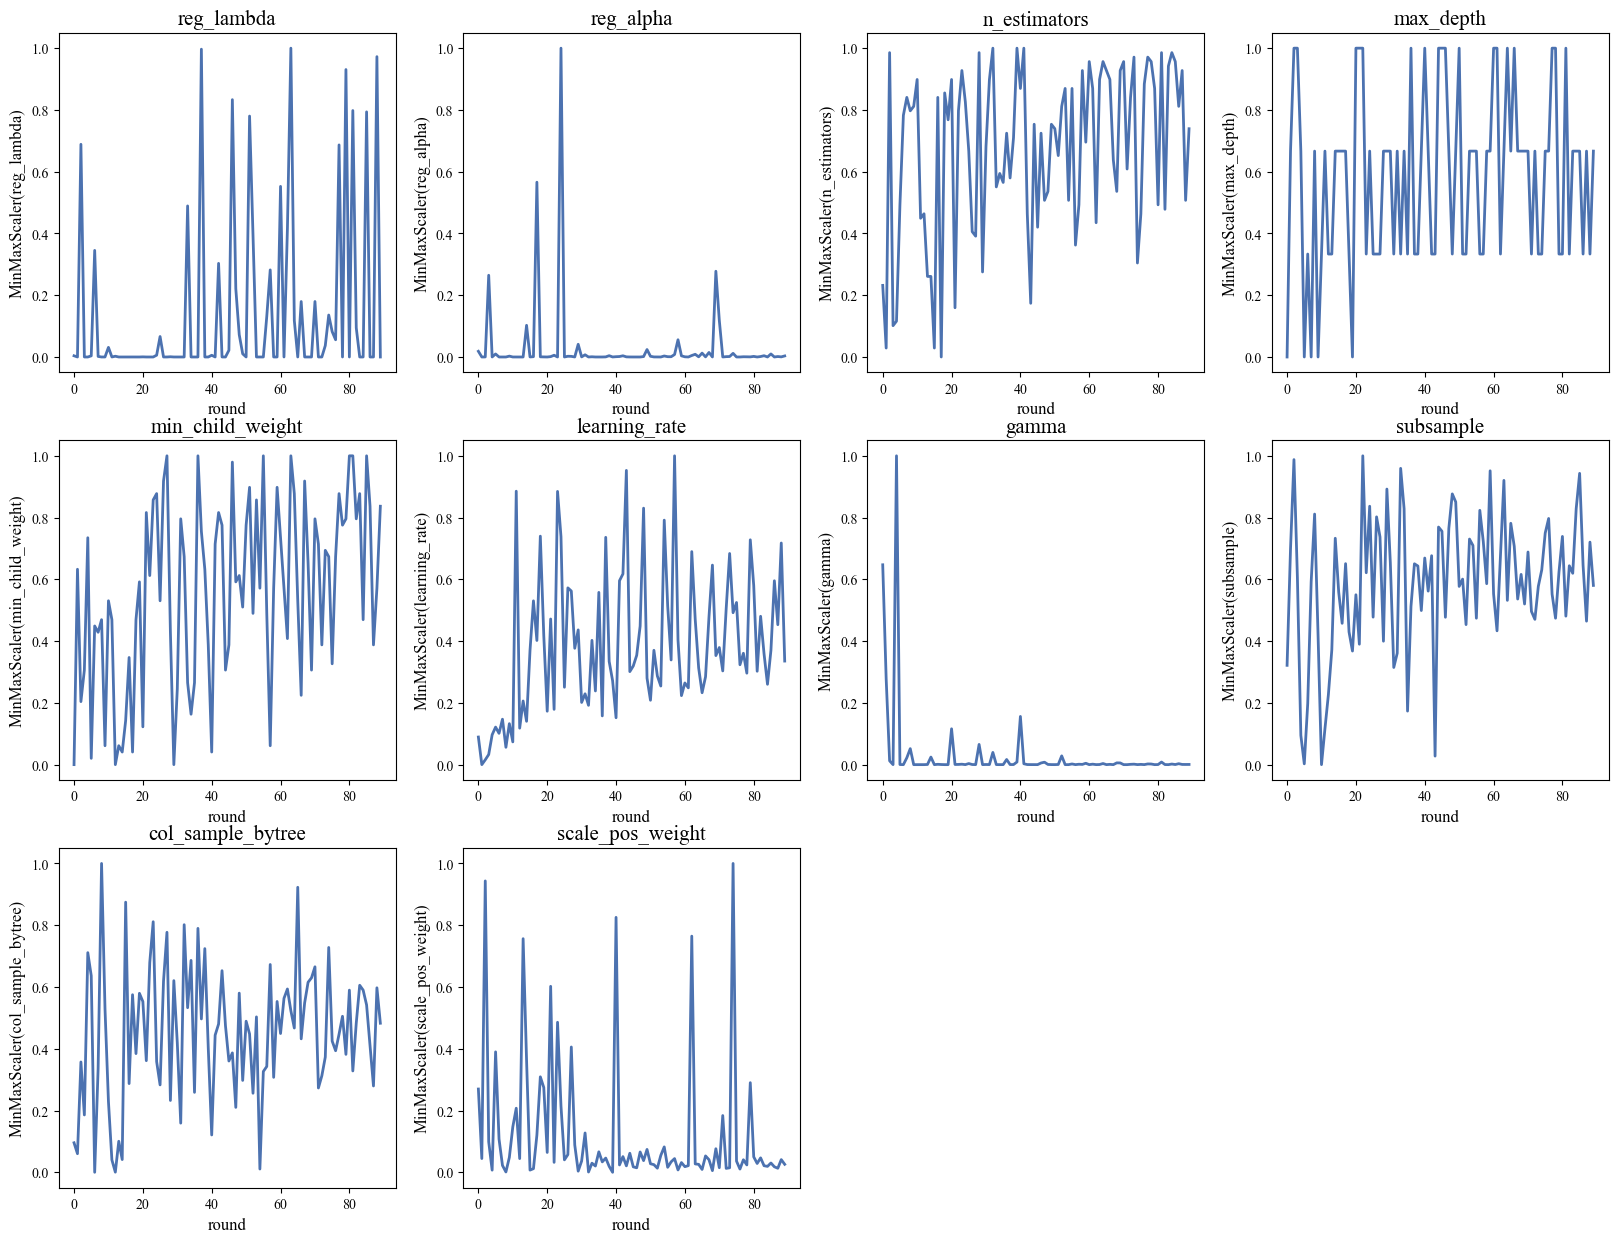

In [45]:
se.parameter_fluctuation_curve(FILE_PATH + 'optuna.xlsx',0.01,'xgb')

### 最终模型

In [46]:
# data_end = pd.read_pickle(DATA_PATH + 'data_end_before_modeling.pkl')

In [47]:
params = eval(ress.iloc[res.index[0]]['model_param'])
params

{'verbosity': 0,
 'booster': 'gbtree',
 'reg_lambda': 2.2353874301169136e-05,
 'reg_alpha': 0.003280385143406717,
 'n_estimators': 82,
 'max_depth': 3,
 'min_child_weight': 42,
 'learning_rate': 0.1048972230627721,
 'col_sample_bytree': 0.5169512963474625,
 'scale_pos_weight': 2.162589205474643,
 'gamma': 0.0005679494455401936,
 'subsample': 0.7924257886265071}

In [48]:
from Model.train import show
import xgboost as xgb
nan = np.nan

print('num_features: ', len(keep_lst))
model = xgb.XGBClassifier(**params)

model.fit(data_end[data_end['target'] == 'train'][keep_lst], 
          data_end[data_end['target'] == 'train']['label'], 
          sample_weight=data_end[data_end['target'] == 'train']['weight'])

import joblib
joblib.dump(model, 'model.model')
model = joblib.load('model.model')

num_features:  57


  datasets       auc  precision    recall        ks        f2        th  \
0    train  0.572434   0.050800  0.843005  0.098758  0.204668  0.079799   
0    valid  0.563364   0.051160  0.775948  0.089529  0.202417  0.085083   
0      oot  0.535414   0.056178  0.834772  0.060456  0.221315  0.075930   

      ratio   count  
0  0.763516  803775  
0  0.697819  344476  
0  0.784101  129491  
  datasets       auc        ks  precision    recall        f2        th  \
0    train  0.572434  0.098758   0.050800  0.843005  0.204668  0.079799   
0    valid  0.563364  0.089529   0.051160  0.775948  0.202417  0.085083   
0      oot  0.535414  0.060456   0.056178  0.834772  0.221315  0.075930   

      ratio   count  
0  0.763516  803775  
0  0.697819  344476  
0  0.784101  129491  


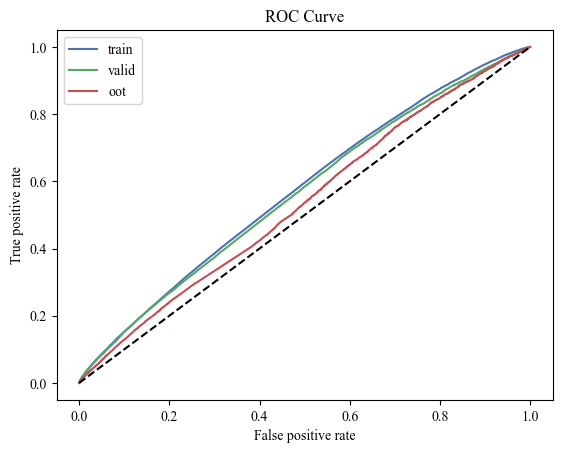

In [49]:
res_data = se.eval_dataset(data_end, model, keep_lst, col_name='target')

  datasets       auc  precision    recall        ks        f2        th  \
0  2024-07  0.558237   0.035078  0.708333  0.080666  0.146392  0.085788   
0  2024-08  0.561373   0.040822  0.772429  0.088169  0.168491  0.083480   
0  2024-09  0.564646   0.046428  0.727196  0.095704  0.184917  0.088720   
0  2024-10  0.576802   0.051045  0.740156  0.108508  0.200041  0.088954   
0  2024-11  0.583554   0.055396  0.691598  0.119459  0.209770  0.094390   
0  2024-12  0.566795   0.051179  0.804225  0.097055  0.203974  0.083450   
0  2025-01  0.576666   0.052912  0.802332  0.104110  0.209337  0.085644   
0  2025-02  0.574262   0.058481  0.862781  0.099570  0.230036  0.080451   
0  2025-03  0.571531   0.061984  0.836267  0.098667  0.239047  0.083292   
0  2025-04  0.557001   0.059382  0.850307  0.078857  0.232079  0.078416   
0  2025-05  0.540241   0.055568  0.903294  0.055998  0.222972  0.071344   
0  2025-06  0.526281   0.055005  0.958250  0.052466  0.223669  0.061092   

      ratio   count  
0 

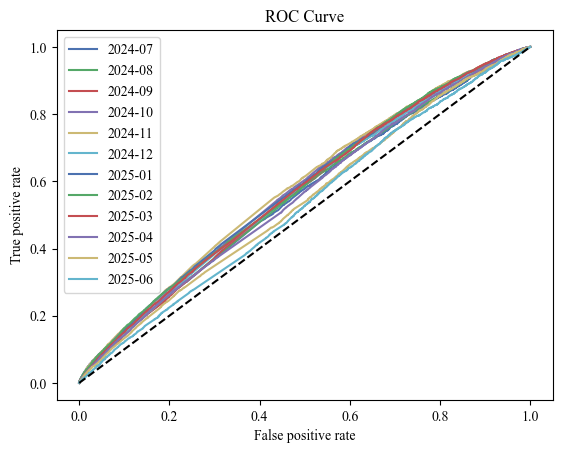

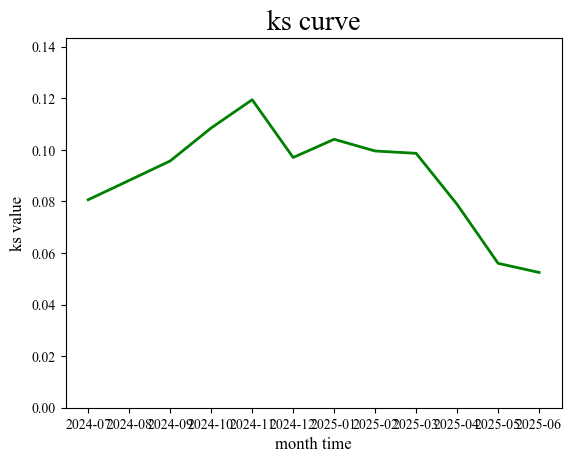

In [50]:
res_month = se.eval_month(data_end, model, keep_lst, col_name='month_time')

In [51]:
importance = pd.DataFrame({'var_names': keep_lst, 'importance': model.feature_importances_})
importance.sort_values(by='importance', ascending=False)

,var_names,importance
7,TZ_0265_m18,0.142210
0,TZ_0265_m15,0.103445
39,TZ_0265_m6,0.051970
36,TZ_0276_m24,0.047926
18,TZ_0097_m3,0.045943
40,TZ_0265_m9,0.037583
19,TZ_0096_m3,0.032369
17,TZ_0099_m3,0.029675
25,TZ_0099_m6,0.027618
32,TZ_0277_m24,0.022000


In [52]:
importance.sort_values(by='importance', ascending=False).head()

,var_names,importance
7,TZ_0265_m18,0.142210
0,TZ_0265_m15,0.103445
39,TZ_0265_m6,0.051970
36,TZ_0276_m24,0.047926
18,TZ_0097_m3,0.045943


In [53]:
end_keep = list(importance[importance['importance']>0]['var_names'])
len(end_keep)

54

In [54]:
keep_lst = end_keep

In [55]:
from Model.train import show
import xgboost as xgb
nan = np.nan

print('num_features: ', len(keep_lst))
model = xgb.XGBClassifier(**params)

model.fit(data_end[data_end['target'] == 'train'][keep_lst], 
          data_end[data_end['target'] == 'train']['label'], 
          sample_weight=data_end[data_end['target'] == 'train']['weight'])

import joblib
joblib.dump(model, 'model.model')
model = joblib.load('model.model')

num_features:  54


  datasets       auc  precision    recall        ks        f2        th  \
0    train  0.572434   0.050800  0.843005  0.098758  0.204668  0.079799   
0    valid  0.563364   0.051160  0.775948  0.089529  0.202417  0.085083   
0      oot  0.535414   0.056178  0.834772  0.060456  0.221315  0.075930   

      ratio   count  
0  0.763516  803775  
0  0.697819  344476  
0  0.784101  129491  
  datasets       auc        ks  precision    recall        f2        th  \
0    train  0.572434  0.098758   0.050800  0.843005  0.204668  0.079799   
0    valid  0.563364  0.089529   0.051160  0.775948  0.202417  0.085083   
0      oot  0.535414  0.060456   0.056178  0.834772  0.221315  0.075930   

      ratio   count  
0  0.763516  803775  
0  0.697819  344476  
0  0.784101  129491  


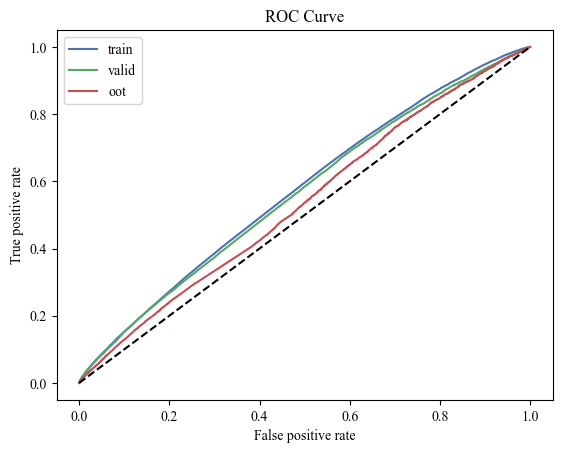

In [56]:
res_data = se.eval_dataset(data_end, model, keep_lst, col_name='target')

  datasets       auc  precision    recall        ks        f2        th  \
0  2024-07  0.558237   0.035078  0.708333  0.080666  0.146392  0.085788   
0  2024-08  0.561373   0.040822  0.772429  0.088169  0.168491  0.083480   
0  2024-09  0.564646   0.046428  0.727196  0.095704  0.184917  0.088720   
0  2024-10  0.576802   0.051045  0.740156  0.108508  0.200041  0.088954   
0  2024-11  0.583554   0.055396  0.691598  0.119459  0.209770  0.094390   
0  2024-12  0.566795   0.051179  0.804225  0.097055  0.203974  0.083450   
0  2025-01  0.576666   0.052912  0.802332  0.104110  0.209337  0.085644   
0  2025-02  0.574262   0.058481  0.862781  0.099570  0.230036  0.080451   
0  2025-03  0.571531   0.061984  0.836267  0.098667  0.239047  0.083292   
0  2025-04  0.557001   0.059382  0.850307  0.078857  0.232079  0.078416   
0  2025-05  0.540241   0.055568  0.903294  0.055998  0.222972  0.071344   
0  2025-06  0.526281   0.055005  0.958250  0.052466  0.223669  0.061092   

      ratio   count  
0 

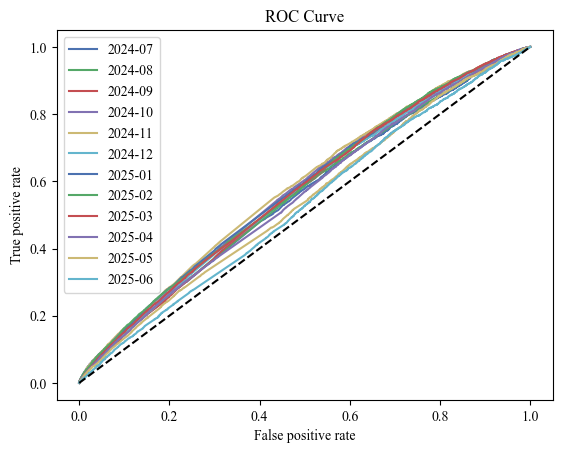

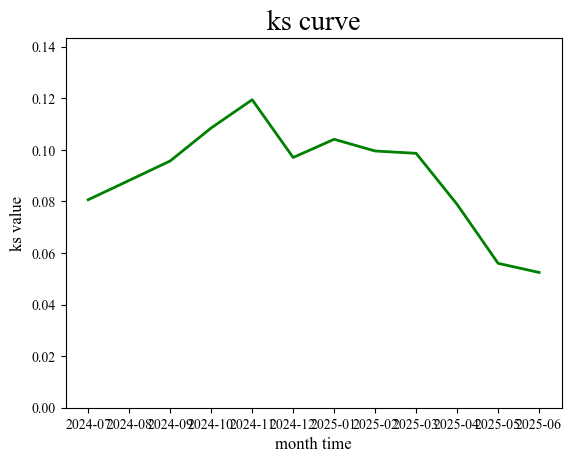

In [57]:
res_month = se.eval_month(data_end, model, keep_lst, col_name='month_time')

In [58]:
importance = pd.DataFrame({'var_names': keep_lst, 'importance': model.feature_importances_})
importance.sort_values(by='importance', ascending=False)

,var_names,importance
6,TZ_0265_m18,0.142210
0,TZ_0265_m15,0.103445
36,TZ_0265_m6,0.051970
33,TZ_0276_m24,0.047926
17,TZ_0097_m3,0.045943
37,TZ_0265_m9,0.037583
18,TZ_0096_m3,0.032369
16,TZ_0099_m3,0.029675
24,TZ_0099_m6,0.027618
30,TZ_0277_m24,0.022000


In [59]:
importance.sort_values(by='importance', ascending=False).head()

,var_names,importance
6,TZ_0265_m18,0.142210
0,TZ_0265_m15,0.103445
36,TZ_0265_m6,0.051970
33,TZ_0276_m24,0.047926
17,TZ_0097_m3,0.045943


### 分数评估

In [60]:
data_end.head()

,TZ_0265_m15,TZ_0282_m24,TZ_0089_m24,TZ_0280_m24,TZ_0091_m24,TZ_0088_m24,TZ_0281_m18,TZ_0265_m18,TZ_0282_m18,TZ_0280_m15,...,TZ_0455_m3,mobile,backPointTime,qudao3_act,label,weight,target,month_time,day_time,week_time
0,0.0,-1.0,0.0,-1.0,0.0,0.0,-1.0,0.0,-1.0,-1.0,...,8.0,663c8e4d4a0d11fa9767b332f30c1921,2024-08-11,信息流,0.0,1,train,2024-08,2024-08-11,32
1,0.0,-1.0,0.0,-1.0,0.0,0.0,-1.0,0.0,-1.0,-1.0,...,8.0,663c8e4d4a0d11fa9767b332f30c1921,2024-08-11,信息流,0.0,1,valid,2024-08,2024-08-11,32
2,0.0,-1.0,0.0,-1.0,0.0,0.0,-1.0,0.0,-1.0,-1.0,...,0.0,f3f4e2f3c61d8f1a035a0c32987714a5,2025-02-21,API,0.0,1,valid,2025-02,2025-02-21,8
3,5.0,-1.0,0.0,-1.0,0.0,0.0,-1.0,5.0,-1.0,-1.0,...,3.0,6d09e74a845b0c12e86be848d40f4fd3,2025-06-09,API,0.0,1,oot,2025-06,2025-06-09,24
4,1.0,-1.0,0.0,-1.0,0.0,0.0,-1.0,1.0,-1.0,-1.0,...,-1.0,70a24bd8e0cfa4efb16a5a26b3054bc5,2025-04-28,API,0.0,1,train,2025-04,2025-04-28,18


In [61]:
from new_tools import auto_score
# 开始分数转换
scorer = auto_score.ScoreCalculator(max_score=900, min_score=300)  # 实例化分数计算器
data_end['proba'] =  model.predict_proba(data_end[keep_lst])[:, 1]
scores, min_score, max_score, final_p, final_q, final_pdo = scorer.automatic_scoring(data_end['proba'])
data_end['score'] = scores

pdo_df = pd.DataFrame({'Min Score': min_score,
                        'Max Score': max_score,
                        'P': final_p,
                        'Q': final_q,
                        'PDO': final_pdo},index=[0])
# 打印结果
print(f"Min Score: {min_score}, Max Score: {max_score}, P: {final_p}, Q: {final_q}, PDO: {final_pdo}")

def card_score(pred, P=final_p, Q=final_q, PDO=final_pdo, good_weight=1):
    '''
    根据概率1返回卡评分
    pred:概率(array或scalar); Q:设定的Odds比率; P:比率Q时的分数
    PDO:比率为2Q时分值增加量; good_weight:好客户抽样比例
    '''
    Odds = (1-pred)*good_weight/pred
    B = -PDO/np.log(2)
    A = P + B*np.log(Q)
    score = A - B*np.log(Odds)
    # score[score<350] = 350
    # score[score>850] = 1000
    return score.astype(int)
	
data_end['score'] = card_score(data_end['proba'])

print(data_end['proba'].min(),data_end['proba'].max())
print(data_end['score'].min(),data_end['score'].max())
data_end[['score','proba']].head()

Min Score: 322, Max Score: 895, P: 675, Q: 10, PDO: 110
0.02433764 0.47983038
322 895


,score,proba
0,656,0.101074
1,656,0.101074
2,650,0.104383
3,740,0.062065
4,689,0.083852


In [62]:
# data_end.to_pickle(DATA_PATH + 'data_end.pkl')

In [63]:
data_end.to_csv(DATA_PATH + '打分文件.csv')

In [64]:
data_end

,TZ_0265_m15,TZ_0282_m24,TZ_0089_m24,TZ_0280_m24,TZ_0091_m24,TZ_0088_m24,TZ_0281_m18,TZ_0265_m18,TZ_0282_m18,TZ_0280_m15,...,backPointTime,qudao3_act,label,weight,target,month_time,day_time,week_time,proba,score
0,0.0,-1.0,0.0,-1.0,0.00000,0.0,-1.0,0.0,-1.0,-1.0,...,2024-08-11,信息流,0.0,1,train,2024-08,2024-08-11,32,0.101074,656
1,0.0,-1.0,0.0,-1.0,0.00000,0.0,-1.0,0.0,-1.0,-1.0,...,2024-08-11,信息流,0.0,1,valid,2024-08,2024-08-11,32,0.101074,656
2,0.0,-1.0,0.0,-1.0,0.00000,0.0,-1.0,0.0,-1.0,-1.0,...,2025-02-21,API,0.0,1,valid,2025-02,2025-02-21,8,0.104383,650
3,5.0,-1.0,0.0,-1.0,0.00000,0.0,-1.0,5.0,-1.0,-1.0,...,2025-06-09,API,0.0,1,oot,2025-06,2025-06-09,24,0.062065,740
4,1.0,-1.0,0.0,-1.0,0.00000,0.0,-1.0,1.0,-1.0,-1.0,...,2025-04-28,API,0.0,1,train,2025-04,2025-04-28,18,0.083852,689
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1277737,4.0,-1.0,0.0,-1.0,0.00000,0.0,-1.0,4.0,-1.0,-1.0,...,2024-11-13,APP自然流量,0.0,1,train,2024-11,2024-11-13,46,0.073811,711
1277738,3.0,-1.0,0.0,-1.0,0.00000,0.0,-1.0,3.0,-1.0,-1.0,...,2024-11-15,APP自然流量,0.0,1,train,2024-11,2024-11-15,46,0.074826,708
1277739,5.0,24.0,1.0,31.0,0.07971,2.0,-1.0,5.0,-1.0,-1.0,...,2024-11-12,APP自然流量,0.0,1,train,2024-11,2024-11-12,46,0.057416,753
1277740,-1.0,-1.0,0.0,-1.0,0.00000,0.0,-1.0,-1.0,-1.0,-1.0,...,2024-11-23,APP自然流量,0.0,1,train,2024-11,2024-11-23,47,0.101370,655


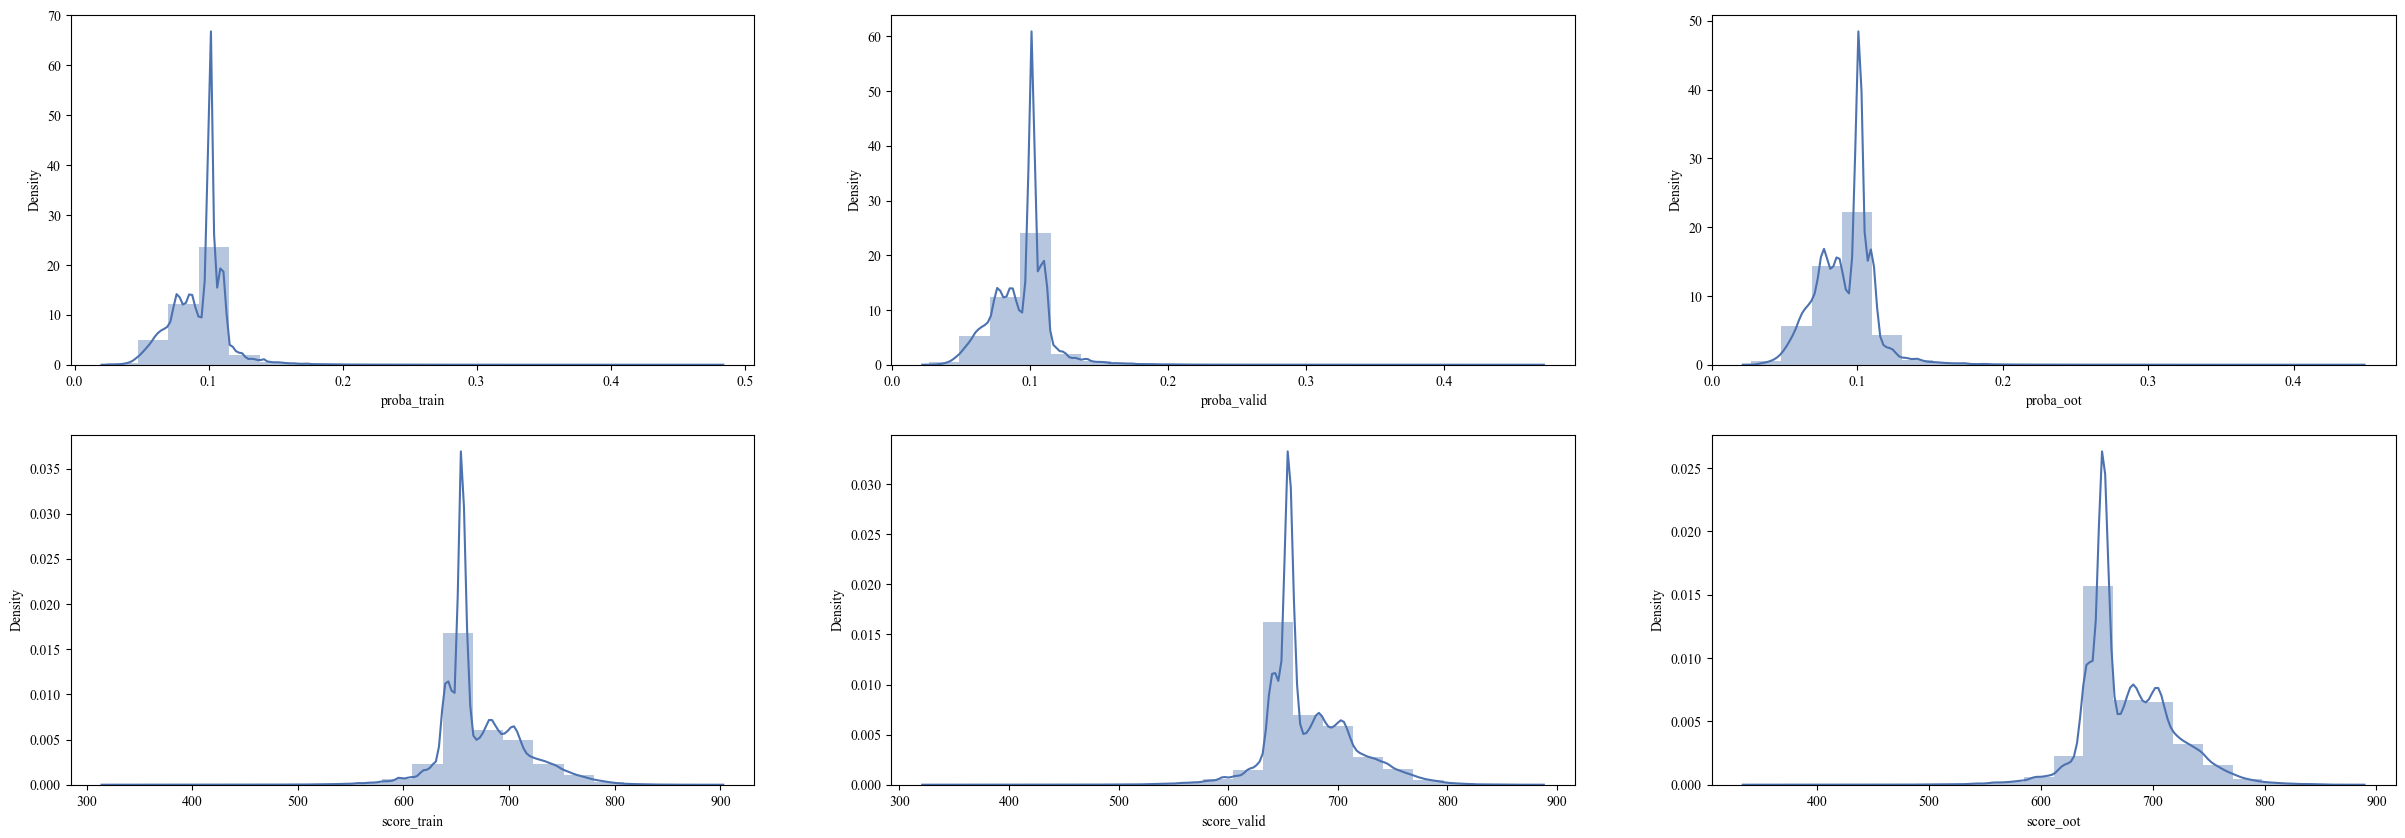

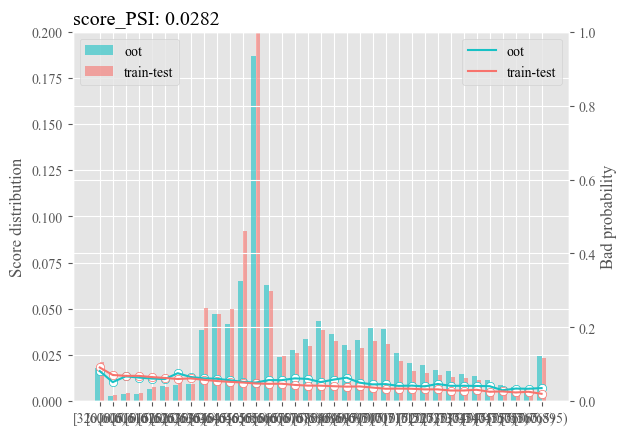

In [ ]:
# plt.style.use('seaborn-deep')
# plt.rcParams['font.sans-serif'] = 'Times New Roman'
# se.plot_distribution(data_end, bin_num=20, x_tick_break=5, col_name='target')

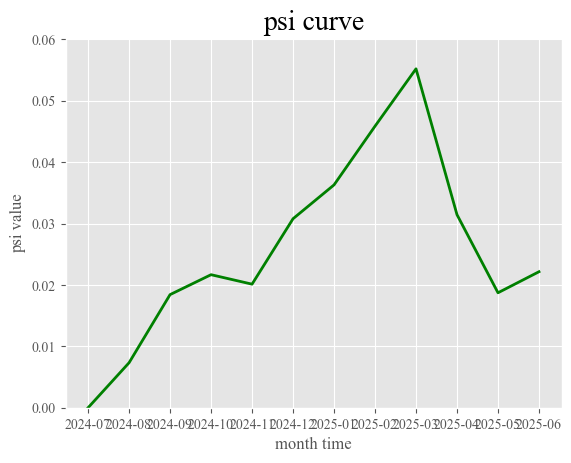

,moth,psi
0,2024-07,0.000000
1,2024-08,0.007326
2,2024-09,0.018420
3,2024-10,0.021667
4,2024-11,0.020124
5,2024-12,0.030780
6,2025-01,0.036292
7,2025-02,0.045856
8,2025-03,0.055198
9,2025-04,0.031443


In [66]:
from new_tools.new_psi import plot_month_psi_curve
plot_month_psi_curve(data_end, 'month_time')

In [67]:
import toad
score_ks =  toad.metrics.KS_bucket(data_end[data_end['target']=='train']['score'], data_end[data_end['target']=='train']['label'], 
                                   bucket=10,
#                                    q=[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,]
                                  )
score_ks.to_csv(FILE_PATH + 'score_ks_train.csv')
score_ks[['min','max','bad_rate','odds','cum_bads_prop','cum_total_prop','lift','cum_lift']]

,min,max,bad_rate,odds,cum_bads_prop,cum_total_prop,lift,cum_lift
0,322,637,0.070022,0.075294,0.140582,0.092374,1.521876,1.521876
1,638,645,0.054743,0.057913,0.267211,0.198803,1.189799,1.344099
2,646,653,0.052955,0.055916,0.342085,0.263859,1.150929,1.296472
3,654,654,0.050181,0.052832,0.392407,0.309998,1.090638,1.265836
4,655,658,0.048239,0.050684,0.578714,0.487697,1.048441,1.186625
5,659,670,0.046935,0.049246,0.692986,0.599719,1.020089,1.155518
6,671,685,0.042678,0.044581,0.782002,0.695685,0.927582,1.124075
7,686,702,0.039934,0.041595,0.868774,0.795660,0.867930,1.091890
8,703,725,0.034218,0.035430,0.944622,0.897648,0.743696,1.052330
9,726,895,0.024894,0.025530,1.000000,1.000000,0.541057,1.000000


In [68]:
score_ks =  toad.metrics.KS_bucket(data_end[data_end['target']=='valid']['score'], data_end[data_end['target']=='valid']['label'],
                                                                     bucket=10,
#                                    q=[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,]
                                  )
score_ks.to_csv(FILE_PATH + 'score_ks_valid.csv')
score_ks[['min','max','bad_rate','odds','cum_bads_prop','cum_total_prop','lift','cum_lift']]

,min,max,bad_rate,odds,cum_bads_prop,cum_total_prop,lift,cum_lift
0,330,637,0.068629,0.073686,0.139315,0.093397,1.491642,1.491642
1,638,645,0.054308,0.057427,0.264749,0.199663,1.180378,1.325979
2,646,653,0.048516,0.050989,0.333523,0.264883,1.054480,1.259130
3,654,654,0.048732,0.051229,0.381917,0.310573,1.059194,1.229716
4,655,658,0.047952,0.050367,0.566850,0.488014,1.042224,1.161545
5,659,670,0.048320,0.050773,0.682882,0.598497,1.050223,1.140994
6,671,685,0.042787,0.044699,0.772478,0.694841,0.929960,1.111733
7,686,702,0.038314,0.039840,0.856142,0.795309,0.832744,1.076490
8,703,725,0.034231,0.035445,0.932235,0.897584,0.744011,1.038606
9,726,879,0.030442,0.031398,1.000000,1.000000,0.661657,1.000000


In [69]:
score_ks =  toad.metrics.KS_bucket(data_end[data_end['target']=='oot']['score'], data_end[data_end['target']=='oot']['label'],
                               bucket=10,
#                                    q=[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,]
                              )
score_ks.to_csv(FILE_PATH + 'score_ks_oot.csv')
score_ks[['min','max','bad_rate','odds','cum_bads_prop','cum_total_prop','lift','cum_lift']]

,min,max,bad_rate,odds,cum_bads_prop,cum_total_prop,lift,cum_lift
0,345,638,0.068174,0.073161,0.110786,0.085751,1.291947,1.291947
1,639,650,0.058864,0.062546,0.236207,0.198184,1.115520,1.191857
2,651,654,0.051889,0.054729,0.291673,0.254589,0.983347,1.145661
3,655,656,0.047338,0.049690,0.419581,0.397170,0.897093,1.056427
4,657,663,0.058680,0.062339,0.532563,0.498768,1.112043,1.067756
5,664,680,0.059822,0.063628,0.645544,0.598428,1.133672,1.078733
6,681,693,0.056474,0.059854,0.748573,0.694697,1.070222,1.077553
7,694,707,0.048933,0.051451,0.844578,0.798225,0.927327,1.058069
8,708,730,0.043198,0.045148,0.927850,0.899947,0.818632,1.031006
9,731,878,0.038052,0.039557,1.000000,1.000000,0.721114,1.000000


#### 全样本统计

In [70]:
score_ks = se.show_statistic(data_end, bin_num=15, q=None)
flag = '信贷'
show_lst = ['min','max','bad_rate','odds','cum_bads_prop','cum_total_prop','total','ks','cum_lift','通过率']
show_lst += ['通过人群整体坏账率'] if flag != '营销' else ['通过人群整体响应率']
score_ks[show_lst]

[-inf, 633.0, 641.0, 646.0, 654.0, 655.0, 657.0, 660.0, 672.0, 683.0, 693.0, 704.0, 716.0, 739.0, inf]


,min,max,bad_rate,odds,cum_bads_prop,cum_total_prop,total,ks,cum_lift,通过率,通过人群整体坏账率
0,-inf,633.0,0.072507,12.791777,0.101502,0.065368,83523.0,0.037904,1.552782,1.000000,0.046695
1,633.0,641.0,0.058788,16.010330,0.184248,0.131093,83980.0,0.055759,1.405479,0.934632,0.044890
2,641.0,646.0,0.053997,17.519538,0.259738,0.196374,83412.0,0.066468,1.322671,0.868907,0.043838
3,646.0,654.0,0.051948,18.250000,0.330534,0.260011,81312.0,0.073978,1.271232,0.803626,0.043013
4,654.0,655.0,0.049865,19.054283,0.378084,0.304538,56894.0,0.077148,1.241500,0.739989,0.042245
5,655.0,657.0,0.048121,19.780743,0.533186,0.455042,192305.0,0.081972,1.171729,0.695462,0.041757
6,657.0,660.0,0.049242,19.307667,0.583467,0.502722,60923.0,0.084701,1.160616,0.544958,0.039999
7,660.0,672.0,0.048080,19.798588,0.680829,0.597279,120819.0,0.087643,1.139886,0.497278,0.039113
8,672.0,683.0,0.044569,21.437165,0.746581,0.666167,88021.0,0.084353,1.120712,0.402721,0.037007
9,683.0,693.0,0.042728,22.403873,0.807170,0.732381,84605.0,0.078452,1.102118,0.333833,0.035447


In [71]:
score_ks = se.show_statistic(data_end[data_end['target']=='oot'], bin_num=10, q=None)
flag = '信贷'
show_lst = ['min','max','bad_rate','odds','cum_bads_prop','cum_total_prop','total','ks','cum_lift','通过率']
show_lst += ['通过人群整体坏账率'] if flag != '营销' else ['通过人群整体响应率']
score_ks[show_lst]

[-inf, 639.0, 651.0, 655.0, 657.0, 664.0, 681.0, 694.0, 708.0, 731.0, inf]


,min,max,bad_rate,odds,cum_bads_prop,cum_total_prop,total,ks,cum_lift,通过率,通过人群整体坏账率
0,-inf,639.0,0.068174,13.668428,0.110786,0.085751,11104.0,0.026429,1.291947,1.000000,0.052768
1,639.0,651.0,0.058864,15.988331,0.236207,0.198184,14559.0,0.040141,1.191857,0.914249,0.051323
2,651.0,655.0,0.051889,18.271768,0.291673,0.254589,7304.0,0.039149,1.145661,0.801816,0.050266
3,655.0,657.0,0.047338,20.124714,0.419581,0.397170,18463.0,0.023659,1.056427,0.745411,0.050143
4,657.0,664.0,0.058680,16.041451,0.532563,0.498768,13156.0,0.035677,1.067756,0.602830,0.050806
5,664.0,681.0,0.059822,15.716321,0.645544,0.598428,12905.0,0.049741,1.078733,0.501232,0.049210
6,681.0,694.0,0.056474,16.707386,0.748573,0.694697,12466.0,0.056877,1.077553,0.401572,0.046577
7,694.0,708.0,0.048933,19.435976,0.844578,0.798225,13406.0,0.048935,1.058069,0.305303,0.043456
8,708.0,731.0,0.043198,22.149385,0.927850,0.899947,13172.0,0.029458,1.031006,0.201775,0.040646
9,731.0,inf,0.038052,25.279919,1.000000,1.000000,12956.0,0.000000,1.000000,0.100053,0.038052


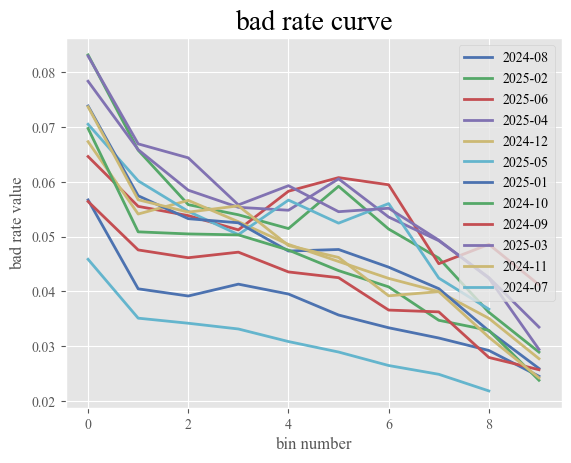

In [72]:
plt.style.use('seaborn-deep')
plt.rcParams['font.sans-serif'] = 'Times New Roman'
se.plot_badrate(data_end, bin_num=10, col_name='month_time')

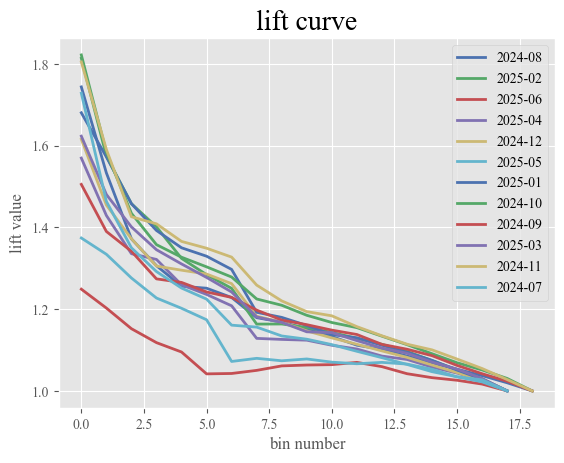

In [73]:
se.plot_lift(data_end, bin_num=20, col_name='month_time')

In [74]:
SAVE_PATH = FILE_PATH + '上线文档/'
isExists = os.path.exists(SAVE_PATH)
if not isExists:
    os.makedirs(SAVE_PATH) 

#### 原始文件

In [75]:
# data_org = pd.read_pickle(DATA_PATH + 'data_model.pickle')
data_org = pd.read_parquet(DATA_PATH + 'data_model.parquet')
# data_con = pd.read_pickle(DATA_PATH + 'data_con.pkl')
# data_con['backPointTime'] = pd.to_datetime(data_con['backPointTime'])
# data_org['backPointTime'] = pd.to_datetime(data_org['backPointTime'])
# data_org = pd.merge(data_org, data_con, on=['applist_json','mobile', 'backPointTime'])

In [76]:
data_org

,mobile,backPointTime,qudao3_act,label,TZ_1381_m12,TZ_1381_m24,TZ_1381_m18,TZ_0264_m15,TZ_0264_m12,TZ_0264_m18,...,TZ_0443_m8,TZ_0455_m3,TZ_0418_m11,TZ_0269_w4,TZ_0049_m12,target,month_time,day_time,week_time,weight
0,663c8e4d4a0d11fa9767b332f30c1921,2024-08-11,信息流,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.5,8.0,-1.0,0.0,0.0,valid,2024-08,2024-08-11,32,1
1,663c8e4d4a0d11fa9767b332f30c1921,2024-08-11,信息流,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.5,8.0,-1.0,0.0,0.0,train,2024-08,2024-08-11,32,1
2,f3f4e2f3c61d8f1a035a0c32987714a5,2025-02-21,API,0.0,-1.0,10.0,-1.0,1.0,1.0,1.0,...,-1.0,0.0,-1.0,-1.0,0.0,valid,2025-02,2025-02-21,8,1
3,6d09e74a845b0c12e86be848d40f4fd3,2025-06-09,API,0.0,20.0,20.0,20.0,35.0,35.0,35.0,...,-1.0,3.0,1.0,0.0,0.0,oot,2025-06,2025-06-09,24,1
4,70a24bd8e0cfa4efb16a5a26b3054bc5,2025-04-28,API,0.0,18.0,20.0,20.0,20.0,18.0,20.0,...,-1.0,-1.0,1.0,2.0,0.0,train,2025-04,2025-04-28,18,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1277737,a18e8ccd88bb61bc7f9dd825d25b8850,2024-11-13,APP自然流量,0.0,24.0,31.0,30.0,27.0,25.0,31.0,...,0.0,-1.0,1.0,2.0,0.0,train,2024-11,2024-11-13,46,1
1277738,e0c1b14d5f5953670ed63c102f3ead9f,2024-11-15,APP自然流量,0.0,-1.0,-1.0,-1.0,20.0,20.0,20.0,...,1.0,-1.0,1.0,-1.0,1.0,train,2024-11,2024-11-15,46,1
1277739,82bc32734d6acd2f8993add147648f26,2024-11-12,APP自然流量,0.0,25.0,38.0,25.0,26.0,26.0,26.0,...,1.0,0.0,1.0,-1.0,1.0,train,2024-11,2024-11-12,46,1
1277740,45ed4aab69e0a3039def1ed484e79716,2024-11-23,APP自然流量,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,0.0,valid,2024-11,2024-11-23,47,1


In [77]:
data_org['weight'] = 1
data_org = data_org[keep_lst + ['backPointTime']]
data_org['backPointTime'] = pd.to_datetime(data_org['backPointTime'])

In [78]:

data_org

,TZ_0265_m15,TZ_0282_m24,TZ_0280_m24,TZ_0091_m24,TZ_0088_m24,TZ_0281_m18,TZ_0265_m18,TZ_0282_m18,TZ_0280_m15,TZ_0281_m24,...,TZ_0264_w4,TZ_0264_m1,TZ_0279_m24,TZ_0277_m9,TZ_0276_m9,TZ_0278_m9,TZ_0087_m9,TZ_0277_m15,TZ_0455_m3,backPointTime
0,0.0,-1.0,-1.0,0.00000,0.0,-1.0,0.0,-1.0,-1.0,-1.0,...,0.0,0.0,0.0000,-1.0,-1.0,-1.0,0.000000,-1.0,8.0,2024-08-11
1,0.0,-1.0,-1.0,0.00000,0.0,-1.0,0.0,-1.0,-1.0,-1.0,...,0.0,0.0,0.0000,-1.0,-1.0,-1.0,0.000000,-1.0,8.0,2024-08-11
2,0.0,-1.0,-1.0,0.00000,0.0,-1.0,0.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,0.0000,-1.0,-1.0,-1.0,0.000000,-1.0,0.0,2025-02-21
3,5.0,-1.0,-1.0,0.00000,0.0,-1.0,5.0,-1.0,-1.0,-1.0,...,7.0,7.0,832373.4375,12.0,26.0,14.0,0.694444,12.0,3.0,2025-06-09
4,1.0,-1.0,-1.0,0.00000,0.0,-1.0,1.0,-1.0,-1.0,-1.0,...,5.0,5.0,0.0000,-1.0,-1.0,-1.0,0.000000,-1.0,-1.0,2025-04-28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1277737,4.0,-1.0,-1.0,0.00000,0.0,-1.0,4.0,-1.0,-1.0,-1.0,...,11.0,13.0,0.0000,-1.0,-1.0,-1.0,0.000000,-1.0,-1.0,2024-11-13
1277738,3.0,-1.0,-1.0,0.00000,0.0,-1.0,3.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,0.0000,-1.0,-1.0,-1.0,0.000000,-1.0,-1.0,2024-11-15
1277739,5.0,24.0,31.0,0.07971,2.0,-1.0,5.0,-1.0,-1.0,24.0,...,4.0,4.0,0.0000,-1.0,-1.0,-1.0,0.000000,18.0,0.0,2024-11-12
1277740,-1.0,-1.0,-1.0,0.00000,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,0.0000,-1.0,-1.0,-1.0,0.000000,-1.0,-1.0,2024-11-23


In [79]:
data_org.to_csv(SAVE_PATH + '原始文档.csv', index=False, encoding='utf-8-sig')

#### 对照文件

In [80]:
data_comp = data_end[data_end['target'].isin(['valid', 'train'])].iloc[:1000, :]
data_comp.to_csv(SAVE_PATH + '对照文档.csv', index=False, encoding='utf-8-sig')
data_comp

,TZ_0265_m15,TZ_0282_m24,TZ_0089_m24,TZ_0280_m24,TZ_0091_m24,TZ_0088_m24,TZ_0281_m18,TZ_0265_m18,TZ_0282_m18,TZ_0280_m15,...,qudao3_act,label,weight,target,month_time,day_time,week_time,proba,score,bucket
0,0.0,-1.0,0.0,-1.0,0.000000,0.0,-1.0,0.0,-1.0,-1.0,...,信息流,0.0,1,train,2024-08,2024-08-11,32,0.101074,656,5
1,0.0,-1.0,0.0,-1.0,0.000000,0.0,-1.0,0.0,-1.0,-1.0,...,信息流,0.0,1,valid,2024-08,2024-08-11,32,0.101074,656,5
2,0.0,-1.0,0.0,-1.0,0.000000,0.0,-1.0,0.0,-1.0,-1.0,...,API,0.0,1,valid,2025-02,2025-02-21,8,0.104383,650,3
4,1.0,-1.0,0.0,-1.0,0.000000,0.0,-1.0,1.0,-1.0,-1.0,...,API,0.0,1,train,2025-04,2025-04-28,18,0.083852,689,9
5,0.0,-1.0,0.0,-1.0,0.000000,0.0,-1.0,0.0,-1.0,-1.0,...,API,0.0,1,valid,2024-12,2024-12-24,52,0.098816,660,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1097,2.0,-1.0,0.0,-1.0,0.000000,0.0,-1.0,2.0,-1.0,-1.0,...,API,0.0,1,train,2024-10,2024-10-25,43,0.084851,686,9
1098,5.0,20.0,1.0,20.0,0.041667,1.0,-1.0,7.0,-1.0,-1.0,...,API,0.0,1,train,2025-02,2025-02-10,7,0.068665,723,12
1099,0.0,-1.0,0.0,-1.0,0.000000,0.0,-1.0,0.0,-1.0,-1.0,...,API,0.0,1,train,2025-03,2025-03-02,9,0.098121,661,7
1100,0.0,-1.0,0.0,-1.0,0.000000,0.0,-1.0,0.0,-1.0,-1.0,...,API,0.0,1,train,2024-12,2024-12-11,50,0.085603,685,9


In [81]:
import joblib
model = joblib.load('model.model')

In [82]:
# keep_lst = pd.read_csv('keep_lst.csv')['var_names'].tolist()
# len(keep_lst)

#### 模型pmml文件

In [83]:
from sklearn2pmml import sklearn2pmml, PMMLPipeline
from sklearn.pipeline import make_pipeline

flag = 1

if flag:
    train = data_end[data_end['target']=='train']

    pipeline = PMMLPipeline([("classifier", model)])
    pipeline.fit(train[keep_lst], train['label'])
    sklearn2pmml(pipeline, SAVE_PATH + 'model.pmml', with_repr=True)
else:
    model.save_model( SAVE_PATH + 'model')

In [84]:
import joblib
joblib.dump(model, SAVE_PATH + 'model.model')

['/home/zhuchen/poc/02-xyf/deltaV1_all/file/上线文档/model.model']

In [85]:
model.save_model(SAVE_PATH +'model.json')

#### 入模变量

In [86]:
pd.DataFrame({'var_names': keep_lst}).to_csv(SAVE_PATH + 'keep_lst.csv')

### 报告输出

In [87]:
SAVE_PATH = FILE_PATH + '建模报告/'
isExists=os.path.exists(SAVE_PATH)
if not isExists:
    os.makedirs(SAVE_PATH) 

In [ ]:
if_single_ks = False
if_single_lift = False
if_weight = False


# 新增自动报告输出  但是这里还需要改
# 计算train和oot的psi值
from new_tools import new_psi,feature_plot_generator
keep_list = keep_lst

psi_df_tv_o = new_psi.psi_for_continue_var(data_end[data_end['target'].isin(['train','valid'])]['proba'],
                                        data_end[data_end['target'].isin(['oot'])]['proba'],
                                        detail=True,method='equal_width')
psi_df_tv_o

min_month = data_end['month_time'].min()

psi_df_month = new_psi.choice_month_psi(data_end,min_month,'proba','month_time')
psi_df_month


df_list = []
temp_df = pd.DataFrame({
    'dataset':'all',
    'count':data_end['label'].count(),
    'badrate':data_end['label'].mean(),
    'badrate_weight':(data_end['label']*data_end['weight']).sum()/data_end['weight'].sum(),
    'month_min':data_end['month_time'].min(),
    'month_max':data_end['month_time'].max()
},index=[0])
df_list.append(temp_df)

def group_weight_badrate_cal(group):
    return (group['label']*group['weight']).sum()/group['weight'].sum()

for col in ['target','month_time']:
    temp_df = data_end.groupby(col).agg({'label':['count','mean'],'month_time':['min','max']}).reset_index()
    temp_df.columns = ['dataset','count','badrate','month_min','month_max']
    temp_df['badrate_weight'] = (
        data_end.groupby(col)
        .apply(group_weight_badrate_cal)  # 使用apply接收完整分组
        .reset_index(drop=True)
    )
    temp_df.sort_values(by='dataset',ascending=True,inplace=True)
    df_list.append(temp_df)
info_df = pd.concat(df_list,axis=0,ignore_index=True)

if not if_weight:
    info_df.drop(columns = ['badrate_weight'],axis=0,inplace=True)

info_df

import toad
tag_list = [['train'],['valid'],['oot']]
tag_list_str = [str(i) for i in tag_list]
df_list = []

for tag in tag_list:
    temp_df = data_end[data_end['target'].isin(tag)]
    score_ks =  toad.metrics.KS_bucket(temp_df['proba'],
                                        temp_df['label'], 
                                        bucket=10,
                                        )
    lift_df_diff = score_ks[['min','max','lift','cum_lift']]
    df_list.append(lift_df_diff)

lift_df = pd.concat(df_list,axis=1,keys=tag_list_str)
lift_df

from new_tools import iv_report

iv_calculator = iv_report.IVCalculator(data_end,label='label',target='target',keep_list=keep_list, max_leaf_nodes=6, min_samples_leaf=0.05)
iv_df = iv_calculator.iv_report(use_thread=True,max_workers=20)
iv_df.sort_values(by='train_iv',ascending=False,inplace=True)
iv_df.to_excel(SAVE_PATH + 'iv_report.xlsx',index=False)
ipt_df = pd.DataFrame({'var_name': keep_list, 'importance': model.feature_importances_})
ipt_df.sort_values(by='importance', ascending=False, inplace=True)
ipt_iv_df = pd.merge(ipt_df,iv_df,on='var_name',how='left')
ipt_iv_df.to_excel(SAVE_PATH+'ipt_iv.xlsx',index=False)

iv_detail_df = iv_calculator.detail_report(ipt_iv_df['var_name'],'all')


if if_single_ks:
    # 基于配置参数，来决定是否进行输出
    ipt_iv_df = pd.merge(ipt_iv_df,iv_detail_df[['var_name','ks']].drop_duplicates(subset=['var_name']),on='var_name',how='left')
    ipt_iv_df['ks'] = ipt_iv_df['ks'].fillna(0)
iv_detail_df.drop(columns=['ks','badCumRate','goodCumRate'],inplace=True)

if if_single_lift:
    # 基于配置参数，来决定是否进行输出
    def calc_lift(df):
        total_bad = df['bad'].sum()
        total_cnt = df['total'].sum()
        overall_bad_rate = total_bad / total_cnt
        df['lift'] = df['bad_rate'] / overall_bad_rate
        
        return df

    iv_detail_df = iv_detail_df.groupby('var_name', group_keys=False).apply(calc_lift)


import re

def extract_left(bin_str):
    """从区间字符串中提取左端点数值"""
    try:
        left = re.findall(r'[\[\(](-inf|-?\d+\.?\d*)', str(bin_str))[0]
        return float('-inf') if left == '-inf' else float(left)
    except IndexError:
        return float('inf')  # 异常值放最后

iv_detail_df = iv_detail_df.sort_values(
    by=['var_name', 'bin'],
    key=lambda s: s if s.name == 'var_name' else s.map(extract_left),
    ascending=[True, True]  # var_name升序，bin升序
)


model_performance_ks = pd.concat([res_data[['datasets','auc','ks']], res_month[['datasets','auc','ks']]])
def calc_lift(group):
    high_thr = group['score'].quantile(0.95)
    low_thr = group['score'].quantile(0.05)
    top5 = group[group['score'] >= high_thr]
    bottom5 = group[group['score'] <= low_thr]
    bad_rate_all = (group['label'] == 1).mean()
    bad_rate_top5 = (top5['label'] == 1).mean()
    bad_rate_bottom5 = (bottom5['label'] == 1).mean()
    lift_top5 = bad_rate_top5 / bad_rate_all if bad_rate_all > 0 else float('nan')
    lift_bottom5 = bad_rate_bottom5 / bad_rate_all if bad_rate_all > 0 else float('nan')
    return pd.Series({'sub_5_lift': lift_top5,'top_5_lift': lift_bottom5})

result_data = data_end.groupby('target').apply(calc_lift).reset_index()
result_month = data_end.groupby('month_time').apply(calc_lift).reset_index()
result_data.rename(columns={'target':'datasets'},inplace=True)
result_month.rename(columns={'month_time':'datasets'},inplace=True)
model_performance_lift = pd.concat([result_data,result_month])
eval_df = pd.merge(model_performance_ks,model_performance_lift,on='datasets',how='left')


with pd.ExcelWriter(SAVE_PATH + '模型评估报告.xlsx') as writer:
    info_df.to_excel(writer, sheet_name='数据概要', index=False)
    eval_df.to_excel(writer, sheet_name='模型性能', index=True)
    ipt_iv_df.to_excel(writer, sheet_name='特征重要性', index=False)
    iv_detail_df.to_excel(writer, sheet_name='特征分箱', index=False)
    lift_df.to_excel(writer, sheet_name='lift', index=True)
    psi_df_tv_o.to_excel(writer, sheet_name='psi_训练与oot', index=False)
    psi_df_month.to_excel(writer, sheet_name='psi_逐月', index=False)
    pdo_df.to_excel(writer, sheet_name='打分参数', index=False)
    feature_plot_generator.create_feature_plot_report(
        excel_writer=writer,
        data=data_end,
        feature_list=keep_lst,
        sheet_name='特征分箱报告'
    )

初始化IV计算器,获取各个数据集的索引...
初始化完成


计算在所有数据集上的IV分箱细节: 100%|██████████| 54/54 [00:02<00:00, 19.19it/s]


#### 特征重要性+iv+psi+分箱细节

In [89]:
feature_importance = pd.DataFrame({'var_names': keep_lst, 'importance': model.feature_importances_}).sort_values(by='importance', ascending=False)
key_value = pd.read_excel(FILE_PATH + 'key_value.xlsx')
key_value = key_value[key_value['var_names'].isin(keep_lst)]
result = pd.merge(feature_importance, key_value, on='var_names')
result.to_csv(SAVE_PATH + 'ipt_iv_psi.csv', index=False, encoding='utf-8-sig')

In [90]:
result

,var_names,importance,Unnamed: 0.1,Unnamed: 0,ks,iv_bin_train,iv_bin_valid,iv_bin_oot,iv_bin_total,psi_tv_bin,...,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95,0.99,max
0,TZ_0265_m18,0.142210,223,223,0.000000,0.029407,0.029542,0.019609,0.025534,3.531640e-06,...,-1.0,0.000000,0.0,1.0,1.00,3.0,6.000000,11.000000,2.800000e+01,5.600000e+01
1,TZ_0265_m15,0.103445,209,209,0.000000,0.029660,0.030082,0.022132,0.025864,8.897142e-06,...,-1.0,0.000000,0.0,1.0,1.00,2.0,5.000000,9.000000,2.300000e+01,5.600000e+01
2,TZ_0265_m6,0.051970,187,187,0.000000,0.026053,0.026000,0.018357,0.022084,1.615716e-05,...,-1.0,-1.000000,0.0,0.0,1.00,2.0,4.000000,7.000000,2.000000e+01,5.600000e+01
3,TZ_0276_m24,0.047926,40,40,0.000000,0.015928,0.020322,0.010710,0.015846,7.597682e-06,...,-1.0,-1.000000,-1.0,-1.0,-1.00,-1.0,12.000000,22.000000,3.400000e+01,4.700000e+01
4,TZ_0097_m3,0.045943,0,0,0.020140,0.004421,0.004264,0.004259,0.004297,7.867307e-07,...,0.0,0.000000,0.0,0.0,0.00,0.0,0.000000,1.000000,3.000000e+00,7.100000e+01
5,TZ_0265_m9,0.037583,212,212,0.000000,0.028041,0.027721,0.019360,0.024081,5.815955e-06,...,-1.0,0.000000,0.0,0.0,1.00,2.0,5.000000,8.000000,2.000000e+01,5.600000e+01
6,TZ_0096_m3,0.032369,1,1,0.020140,0.004421,0.004264,0.004259,0.004297,7.867307e-07,...,0.0,0.000000,0.0,0.0,0.00,0.0,0.000000,1.000000,4.000000e+00,1.240000e+02
7,TZ_0099_m3,0.029675,2,2,0.020029,0.004362,0.004244,0.004563,0.004290,3.681340e-07,...,0.0,0.000000,0.0,0.0,0.00,0.0,0.000000,0.333333,2.333333e+00,1.400333e+03
8,TZ_0099_m6,0.027618,8,8,0.016829,0.005494,0.002781,0.003666,0.004411,8.548416e-07,...,0.0,0.000000,0.0,0.0,0.00,0.0,0.166667,0.666667,2.700000e+00,2.213767e+03
9,TZ_0277_m24,0.022000,134,134,0.000000,0.015435,0.019124,0.010305,0.015079,1.119278e-06,...,-1.0,-1.000000,-1.0,-1.0,-1.00,-1.0,10.000000,13.000000,1.700000e+01,2.000000e+01


In [91]:
feature_importance = pd.DataFrame({'var_names': keep_lst, 'importance': model.feature_importances_}).sort_values(by='importance', ascending=False)
feature_importance = feature_importance[feature_importance['var_names'].isin(end_keep)]
key_value = pd.read_excel(FILE_PATH + 'bins_detail.xlsx')
key_value = key_value[key_value['variable'].isin(end_keep)]
result = pd.merge(feature_importance, key_value, left_on='var_names',right_on='variable')
result.to_csv(SAVE_PATH + 'bin_details.csv', index=False, encoding='utf-8-sig')

In [92]:
%reset -f